# TN-SCUI2020 单模型高性能分割实验

本 Notebook 仅保留一个模型：**ImageNet 预训练 EfficientNet-B4 编码器 + U-Net++ 解码器**。数据仍按固定随机种子 42 和 CATE 分层划分为训练集、验证集和测试集，最终报告逐图平均 Dice、IoU 与 HD95。

首次运行会训练并保存验证 Dice 最优权重；以后再次运行全部单元格会自动加载该权重，不重复训练。若需要从头训练，将 `FORCE_RETRAIN` 改为 `True`。


In [1]:
from pathlib import Path
import gc
import os
import platform
import random
import sys
import time

ROOT = Path('/Users/avery/Documents/Codex/2026-08-26/wo-x')
SMP_RUNTIME = ROOT / 'work' / 'smp_runtime'
if SMP_RUNTIME.exists():
    sys.path.insert(0, str(SMP_RUNTIME))

os.environ.setdefault('HF_HOME', str(ROOT / 'work' / 'hf_cache'))
os.environ.setdefault('TORCH_HOME', str(ROOT / 'work' / 'torch_cache'))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'work' / 'matplotlib'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from scipy.ndimage import (
    binary_erosion,
    binary_fill_holes,
    distance_transform_edt,
    label as connected_component_label,
)
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
import segmentation_models_pytorch as smp

SEED = 42
IMAGE_SIZE = 320
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
THRESHOLD = 0.5
FORCE_RETRAIN = False

ENCODER_LR = 5e-5
DECODER_LR = 3e-4
WEIGHT_DECAY = 1e-4
GRADIENT_ACCUMULATION_STEPS = 2

DATA_ROOT = Path('/Users/avery/Desktop/图像分割/TNSCUI2020_train')
OUTPUT_DIR = Path('/Users/avery/Desktop/图像分割/outputs/strong_single_model')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = OUTPUT_DIR / 'efficientnet_b4_unetpp_best.pt'
HISTORY_PATH = OUTPUT_DIR / 'training_history.csv'
PROGRESS_LOG = OUTPUT_DIR / 'training_progress.log'

if torch.backends.mps.is_available():
    device = torch.device('mps')
    BATCH_SIZE = 2
elif torch.cuda.is_available():
    device = torch.device('cuda')
    BATCH_SIZE = 4
else:
    device = torch.device('cpu')
    BATCH_SIZE = 1

NUM_WORKERS = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_float32_matmul_precision('high')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = [
    'Arial Unicode MS', 'PingFang SC', 'Microsoft YaHei', 'DejaVu Sans'
]
plt.rcParams['axes.unicode_minus'] = False

print('Python:', platform.python_version())
print('PyTorch / SMP:', torch.__version__, smp.__version__)
print('Device:', device)
print('Image size / batch / accumulation:',
      IMAGE_SIZE, BATCH_SIZE, GRADIENT_ACCUMULATION_STEPS)


Python: 3.13.9
PyTorch / SMP: 2.13.0 0.5.0
Device: mps
Image size / batch / accumulation: 320 2 2


## 一、固定数据划分

使用与原实验完全相同的划分规则：随机种子 42，先按 CATE 分层取出 30%，再等分为验证集和测试集，即 70%/15%/15%。


In [2]:
csv_path = DATA_ROOT / 'train.csv'
image_dir = DATA_ROOT / 'image'
mask_dir = DATA_ROOT / 'mask'

df = pd.read_csv(csv_path)
df.columns = [column.strip() for column in df.columns]
df['ID'] = df['ID'].astype(str).str.strip()
df['image_path'] = df['ID'].map(lambda name: image_dir / name)
df['mask_path'] = df['ID'].map(lambda name: mask_dir / name)

assert df.ID.is_unique, 'ID 存在重复'
assert df.image_path.map(Path.exists).all(), '存在缺失原图'
assert df.mask_path.map(Path.exists).all(), '存在缺失 Mask'

train_df, temporary_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['CATE']
)
val_df, test_df = train_test_split(
    temporary_df, test_size=0.50, random_state=SEED,
    stratify=temporary_df['CATE'],
)

split_df = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='validation'),
    test_df.assign(split='test'),
]).sort_values(['split', 'ID'])
split_df[['ID', 'CATE', 'split']].to_csv(
    OUTPUT_DIR / 'data_split.csv', index=False, encoding='utf-8-sig'
)

print('Total:', len(df))
print('Train / validation / test:', len(train_df), len(val_df), len(test_df))
display(pd.crosstab(split_df['split'], split_df['CATE'], margins=True))


Total: 3644
Train / validation / test: 2550 547 547


CATE,0,1,All
split,,,
test,247,300,547
train,1148,1402,2550
validation,246,301,547
All,1641,2003,3644


## 二、Dataset 与数据增强

原图和 Mask 同步等比例缩放并补黑边到 320×320。训练集进行水平翻转、轻微仿射变化、亮度/对比度/Gamma 调整和少量噪声；验证集与测试集不增强。


Image batch: (2, 1, 320, 320) (0.0, 1.0)
Mask batch: (2, 1, 320, 320) [0.0, 1.0]


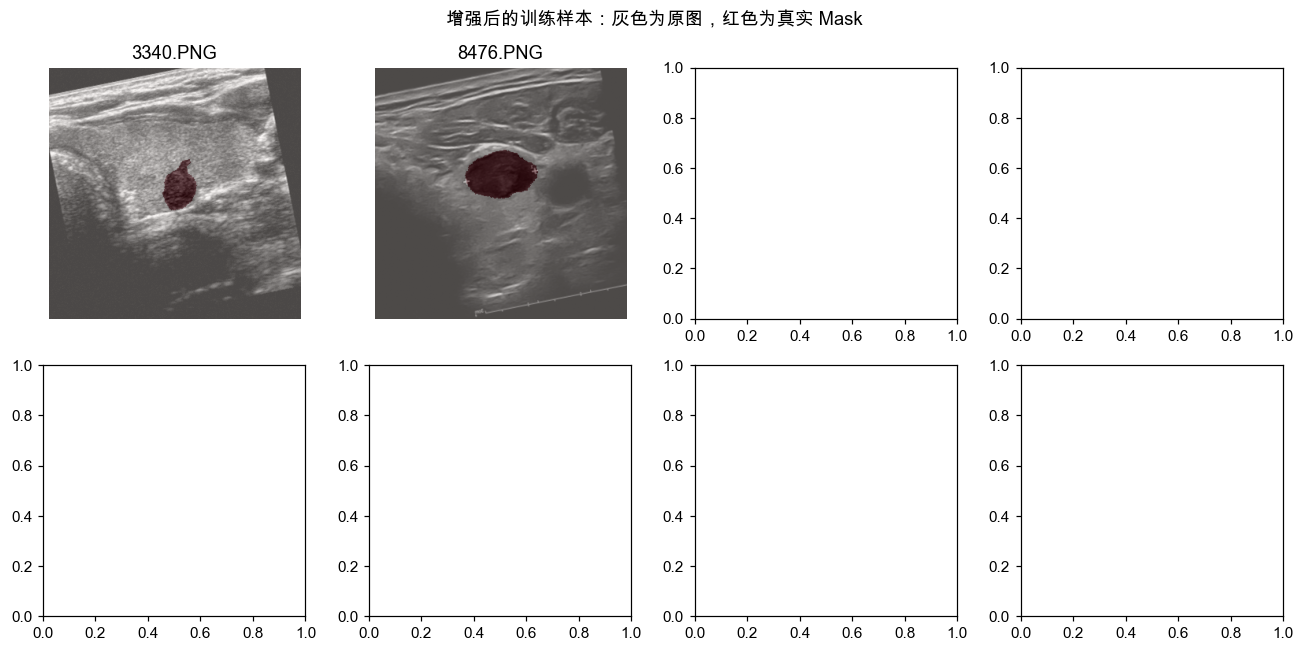

In [3]:
def resize_and_pad(image, mask, size=IMAGE_SIZE):
    image = image.convert('L')
    mask = mask.convert('L')
    scale = min(size / image.width, size / image.height)
    width = max(1, round(image.width * scale))
    height = max(1, round(image.height * scale))
    image = image.resize((width, height), Image.Resampling.BILINEAR)
    mask = mask.resize((width, height), Image.Resampling.NEAREST)

    left = (size - width) // 2
    top = (size - height) // 2
    border = (left, top, size - width - left, size - height - top)
    image = ImageOps.expand(image, border=border, fill=0)
    mask = ImageOps.expand(mask, border=border, fill=0)
    return image, mask


class TNSCUIDataset(Dataset):
    def __init__(self, frame, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image, Image.open(row.mask_path) as mask:
            image, mask = resize_and_pad(image, mask)

        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            angle = random.uniform(-12, 12)
            translation = (random.randint(-10, 10), random.randint(-10, 10))
            scale = random.uniform(0.90, 1.10)
            image = TF.affine(
                image, angle=angle, translate=translation, scale=scale,
                shear=[0.0, 0.0], interpolation=InterpolationMode.BILINEAR,
                fill=0,
            )
            mask = TF.affine(
                mask, angle=angle, translate=translation, scale=scale,
                shear=[0.0, 0.0], interpolation=InterpolationMode.NEAREST,
                fill=0,
            )
            image = TF.adjust_brightness(image, random.uniform(0.85, 1.15))
            image = TF.adjust_contrast(image, random.uniform(0.85, 1.15))
            image = TF.adjust_gamma(image, random.uniform(0.85, 1.15))

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        if self.augment and random.random() < 0.25:
            noise = np.random.normal(0.0, 0.015, image_array.shape).astype(np.float32)
            image_array = np.clip(image_array + noise, 0.0, 1.0)

        mask_array = (np.asarray(mask, dtype=np.uint8) > 0).astype(np.float32)
        return (
            torch.from_numpy(image_array).unsqueeze(0),
            torch.from_numpy(mask_array).unsqueeze(0),
            row.ID,
        )


train_dataset = TNSCUIDataset(train_df, augment=True)
val_dataset = TNSCUIDataset(val_df)
test_dataset = TNSCUIDataset(test_df)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS,
)

images, masks, ids = next(iter(train_loader))
print('Image batch:', tuple(images.shape), (images.min().item(), images.max().item()))
print('Mask batch:', tuple(masks.shape), torch.unique(masks).tolist())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, image, mask, sample_id in zip(axes.flat, images[:8], masks[:8], ids[:8]):
    axis.imshow(image[0], cmap='gray', vmin=0, vmax=1)
    axis.imshow(mask[0], cmap='Reds', alpha=0.30)
    axis.set_title(sample_id)
    axis.axis('off')
fig.suptitle('增强后的训练样本：灰色为原图，红色为真实 Mask')
fig.tight_layout()
plt.show()


## 三、单一高性能模型

模型采用 **EfficientNet-B4 + U-Net++**：

- 灰度图复制为三个相同通道并按 ImageNet 均值、标准差归一化；
- EfficientNet-B4 编码器输出通道依次为 48、32、56、160、448，并加载 ImageNet 预训练权重；
- U-Net++ 使用密集嵌套跳跃连接，解码通道为 256、128、64、32、16；
- 分割头输出 `1×320×320` logits；编码器和解码器都会继续训练。

相比原来的 ResNet18 U-Net，该方案使用更强的编码器、更高输入分辨率以及更密集的多尺度特征融合。


In [4]:
class StrongSegmenter(nn.Module):
    def __init__(self, encoder_weights='imagenet'):
        super().__init__()
        self.network = smp.UnetPlusPlus(
            encoder_name='efficientnet-b4',
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
            decoder_channels=(256, 128, 64, 32, 16),
        )
        self.register_buffer(
            'mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        )
        self.register_buffer(
            'std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        )

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)
        x = (x - self.mean) / self.std
        return self.network(x)


loading_checkpoint = CHECKPOINT_PATH.exists() and HISTORY_PATH.exists() and not FORCE_RETRAIN
model = StrongSegmenter(encoder_weights=None if loading_checkpoint else 'imagenet')
parameters = sum(parameter.numel() for parameter in model.parameters())

with torch.no_grad():
    example_output = model(torch.zeros(1, 1, IMAGE_SIZE, IMAGE_SIZE))

print('Model: EfficientNet-B4 U-Net++')
print('Parameters:', f'{parameters:,}')
print('Output:', tuple(example_output.shape))
del example_output
gc.collect()


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 77.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Model: EfficientNet-B4 U-Net++
Parameters: 20,813,113
Output: (1, 1, 320, 320)


58

## 四、损失函数与评价指标

训练使用 `0.5×Soft Dice Loss + 0.3×BCE + 0.2×Focal Loss`。最终固定阈值为 0.5，报告逐图平均 Dice、IoU 和 HD95；Dice/IoU 越大越好，HD95 越小越好。


In [5]:
bce_loss = nn.BCEWithLogitsLoss()


def soft_dice_loss(logits, targets, smooth=1.0):
    probabilities = torch.sigmoid(logits)
    dimensions = (1, 2, 3)
    intersection = (probabilities * targets).sum(dimensions)
    denominator = probabilities.sum(dimensions) + targets.sum(dimensions)
    dice = (2 * intersection + smooth) / (denominator + smooth)
    return 1 - dice.mean()


def focal_loss(logits, targets, gamma=2.0):
    element_bce = nn.functional.binary_cross_entropy_with_logits(
        logits, targets, reduction='none'
    )
    probabilities = torch.sigmoid(logits)
    p_t = probabilities * targets + (1 - probabilities) * (1 - targets)
    return (((1 - p_t) ** gamma) * element_bce).mean()


def segmentation_loss(logits, targets):
    return (
        0.5 * soft_dice_loss(logits, targets)
        + 0.3 * bce_loss(logits, targets)
        + 0.2 * focal_loss(logits, targets)
    )


def dice_iou_from_logits(logits, targets, threshold=THRESHOLD, eps=1e-7):
    predictions = torch.sigmoid(logits) >= threshold
    targets = targets >= 0.5
    dimensions = (1, 2, 3)
    intersection = (predictions & targets).sum(dimensions).float()
    pred_sum = predictions.sum(dimensions).float()
    target_sum = targets.sum(dimensions).float()
    dice = (2 * intersection + eps) / (pred_sum + target_sum + eps)
    union = pred_sum + target_sum - intersection
    iou = (intersection + eps) / (union + eps)
    return dice, iou


def hd95_binary(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)
    if not prediction.any() and not target.any():
        return 0.0
    if not prediction.any() or not target.any():
        return float(np.hypot(*prediction.shape))

    pred_border = prediction ^ binary_erosion(prediction)
    target_border = target ^ binary_erosion(target)
    target_distance = distance_transform_edt(~target_border)
    pred_distance = distance_transform_edt(~pred_border)
    distances = np.concatenate([
        target_distance[pred_border],
        pred_distance[target_border],
    ])
    return float(np.percentile(distances, 95))


def clear_device_cache():
    gc.collect()
    if device.type == 'mps':
        torch.mps.empty_cache()
    elif device.type == 'cuda':
        torch.cuda.empty_cache()


## 五、训练并保存最佳权重

编码器使用较小学习率，解码器和分割头使用较大学习率。每轮根据验证 loss 调整学习率，根据验证 Dice 保存最佳模型；连续 10 轮没有刷新验证 Dice 时自动停止。


In [ ]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    loss_sum = 0.0
    dice_values, iou_values = [], []

    if training:
        optimizer.zero_grad(set_to_none=True)
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for batch_index, (images, masks, _) in enumerate(loader):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(images)
            loss = segmentation_loss(logits, masks)

            if training:
                (loss / GRADIENT_ACCUMULATION_STEPS).backward()
                last_batch = batch_index + 1 == len(loader)
                accumulation_boundary = (
                    (batch_index + 1) % GRADIENT_ACCUMULATION_STEPS == 0
                )
                if accumulation_boundary or last_batch:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)

            batch_dice, batch_iou = dice_iou_from_logits(
                logits.detach(), masks
            )
            loss_sum += loss.item() * len(images)
            dice_values.extend(batch_dice.cpu().tolist())
            iou_values.extend(batch_iou.cpu().tolist())

    return {
        'loss': loss_sum / len(loader.dataset),
        'dice': float(np.mean(dice_values)),
        'iou': float(np.mean(iou_values)),
    }


def make_optimizer(model):
    return torch.optim.AdamW([
        {'params': model.network.encoder.parameters(), 'lr': ENCODER_LR},
        {'params': model.network.decoder.parameters(), 'lr': DECODER_LR},
        {'params': model.network.segmentation_head.parameters(), 'lr': DECODER_LR},
    ], weight_decay=WEIGHT_DECAY)


def train_or_load(model):
    if CHECKPOINT_PATH.exists() and HISTORY_PATH.exists() and not FORCE_RETRAIN:
        checkpoint = torch.load(
            CHECKPOINT_PATH, map_location='cpu', weights_only=True
        )
        model.load_state_dict(checkpoint['model_state_dict'])
        history = pd.read_csv(HISTORY_PATH)
        print(
            f"Loaded best checkpoint: epoch {checkpoint['best_epoch']}, "
            f"validation Dice {checkpoint['best_validation_dice']:.4f}"
        )
        return model.to(device), history, checkpoint

    model = model.to(device)
    optimizer = make_optimizer(model)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )
    history = []
    best_dice = -1.0
    best_epoch = 0
    stale_epochs = 0

    PROGRESS_LOG.write_text('EfficientNet-B4 U-Net++ training\n', encoding='utf-8')
    with PROGRESS_LOG.open('a', encoding='utf-8') as log:
        for epoch in range(1, MAX_EPOCHS + 1):
            started = time.time()
            train_metrics = run_epoch(model, train_loader, optimizer)
            val_metrics = run_epoch(model, val_loader)
            scheduler.step(val_metrics['loss'])
            elapsed = time.time() - started
            learning_rates = '/'.join(
                f"{group['lr']:.2e}" for group in optimizer.param_groups
            )

            row = {
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'val_loss': val_metrics['loss'],
                'train_dice': train_metrics['dice'],
                'val_dice': val_metrics['dice'],
                'val_iou': val_metrics['iou'],
                'learning_rates': learning_rates,
                'seconds': elapsed,
            }
            history.append(row)
            message = (
                f"epoch {epoch:02d}/{MAX_EPOCHS} | "
                f"train loss {train_metrics['loss']:.4f} "
                f"dice {train_metrics['dice']:.4f} | "
                f"val loss {val_metrics['loss']:.4f} "
                f"dice {val_metrics['dice']:.4f} "
                f"iou {val_metrics['iou']:.4f} | "
                f"lr {learning_rates} | {elapsed:.1f}s"
            )
            print(message, flush=True)
            log.write(message + '\n')
            log.flush()

            if val_metrics['dice'] > best_dice:
                best_dice = val_metrics['dice']
                best_epoch = epoch
                stale_epochs = 0
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'best_epoch': best_epoch,
                    'best_validation_dice': best_dice,
                    'validation_loss': val_metrics['loss'],
                }, CHECKPOINT_PATH)
            else:
                stale_epochs += 1

            pd.DataFrame(history).to_csv(
                HISTORY_PATH, index=False, encoding='utf-8-sig'
            )
            if stale_epochs >= EARLY_STOPPING_PATIENCE:
                print(
                    f'Early stopping at epoch {epoch}; best epoch = {best_epoch}',
                    flush=True,
                )
                break

    checkpoint = torch.load(
        CHECKPOINT_PATH, map_location='cpu', weights_only=True
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    return model.to(device), pd.DataFrame(history), checkpoint


model, history, checkpoint = train_or_load(model)
print('Best epoch:', checkpoint['best_epoch'])
print('Best validation Dice:', f"{checkpoint['best_validation_dice']:.4f}")


## 六、训练曲线


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.epoch, history.train_loss, label='train loss')
axes[0].plot(history.epoch, history.val_loss, label='validation loss')
axes[0].set(title='Loss', xlabel='epoch', ylabel='loss')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history.epoch, history.train_dice, label='train Dice')
axes[1].plot(history.epoch, history.val_dice, label='validation Dice')
axes[1].plot(history.epoch, history.val_iou, label='validation IoU')
axes[1].set(title='Overlap metrics', xlabel='epoch', ylabel='score')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=180, bbox_inches='tight')
plt.show()


## 七、测试集评价

测试时对原图和水平翻转图的概率取平均，再固定使用 0.5 阈值。由于每张图只标注一个目标，二值 Mask 仅保留最大连通区域并填补内部空洞，以减少远处伪小块对 HD95 的影响。


In [ ]:
def keep_largest_component(mask):
    mask = mask.astype(bool)
    labeled, component_count = connected_component_label(mask)
    if component_count == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest = labeled == sizes.argmax()
    return binary_fill_holes(largest)


def predict_test(model, loader):
    model.eval()
    predictions_all, targets_all, ids_all = [], [], []
    with torch.no_grad():
        for images, masks, sample_ids in loader:
            images_device = images.to(device, non_blocking=True)
            probabilities = torch.sigmoid(model(images_device))

            flipped_images = torch.flip(images_device, dims=[-1])
            flipped_probabilities = torch.sigmoid(model(flipped_images))
            flipped_probabilities = torch.flip(flipped_probabilities, dims=[-1])
            probabilities = 0.5 * (probabilities + flipped_probabilities)

            raw_predictions = (probabilities >= THRESHOLD).cpu().numpy()
            processed = np.zeros_like(raw_predictions, dtype=bool)
            for index in range(len(raw_predictions)):
                processed[index, 0] = keep_largest_component(
                    raw_predictions[index, 0]
                )

            predictions_all.append(torch.from_numpy(processed))
            targets_all.append(masks >= 0.5)
            ids_all.extend(sample_ids)

    model.cpu()
    clear_device_cache()
    return (
        torch.cat(predictions_all),
        torch.cat(targets_all),
        ids_all,
    )


def calculate_case_metrics(predictions, targets, ids):
    rows = []
    for index, sample_id in enumerate(ids):
        prediction = predictions[index, 0].numpy().astype(bool)
        target = targets[index, 0].numpy().astype(bool)
        intersection = np.logical_and(prediction, target).sum()
        pred_sum = prediction.sum()
        target_sum = target.sum()
        union = np.logical_or(prediction, target).sum()
        rows.append({
            'ID': sample_id,
            'dice': float(
                (2 * intersection + 1e-7) /
                (pred_sum + target_sum + 1e-7)
            ),
            'iou': float((intersection + 1e-7) / (union + 1e-7)),
            'hd95_pixels': hd95_binary(prediction, target),
            'predicted_pixels': int(pred_sum),
            'target_pixels': int(target_sum),
        })
    return pd.DataFrame(rows)


test_predictions, test_targets, test_ids = predict_test(model.to(device), test_loader)
test_cases = calculate_case_metrics(test_predictions, test_targets, test_ids)
test_cases.to_csv(
    OUTPUT_DIR / 'test_case_metrics.csv', index=False, encoding='utf-8-sig'
)

test_summary = pd.DataFrame([{
    'model': 'EfficientNet-B4 U-Net++',
    'parameters': parameters,
    'best_epoch': checkpoint['best_epoch'],
    'validation_dice': checkpoint['best_validation_dice'],
    'test_dice_mean': test_cases.dice.mean(),
    'test_iou_mean': test_cases.iou.mean(),
    'test_hd95_mean_pixels': test_cases.hd95_pixels.mean(),
    'test_hd95_median_pixels': test_cases.hd95_pixels.median(),
}])
test_summary.to_csv(
    OUTPUT_DIR / 'test_summary.csv', index=False, encoding='utf-8-sig'
)
display(test_summary.style.format({
    'validation_dice': '{:.4f}',
    'test_dice_mean': '{:.4f}',
    'test_iou_mean': '{:.4f}',
    'test_hd95_mean_pixels': '{:.2f}',
    'test_hd95_median_pixels': '{:.2f}',
}))
